# Importing Libraries and Git.

In [1]:

#!git clone https://github.com/marco-siino/EEG-ATCNet.git
%pip install mne
%pip install PyWavelets

import os
import sys
import shutil
import time
import pywt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
os.chdir("/home/giuseppe_bonomo/DATASET/BCI2a_IV")

import models
from preprocess import get_data
# from keras.utils.vis_utils import plot_model

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


2025-09-15 15:50:02.913798: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-15 15:50:03.015123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757944203.057199    3392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757944203.071265    3392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757944203.149647    3392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Organize the dataset.

In [2]:
# Creare la cartella "dataset" e "results" se non esistono già
os.makedirs("dataset", exist_ok=True)

# Creare le cartelle da s1 a s9
for i in range(1, 10):
    os.makedirs(f"dataset/s{i}", exist_ok=True)

In [3]:
"""# Download the dataset.
base_url = "https://bnci-horizon-2020.eu/database/data-sets/001-2014/"
save_path = "dataset/"

for i in range(1, 10):  # Da A01 a A09
    for suffix in ["T", "E"]:  # T per training, E per evaluation
        filename = f"A{i:02d}{suffix}.mat"
        url = base_url + filename
        os.system(f"wget -O {save_path}s{i}/{filename} {url}")"""

'# Download the dataset.\nbase_url = "https://bnci-horizon-2020.eu/database/data-sets/001-2014/"\nsave_path = "dataset/"\n\nfor i in range(1, 10):  # Da A01 a A09\n    for suffix in ["T", "E"]:  # T per training, E per evaluation\n        filename = f"A{i:02d}{suffix}.mat"\n        url = base_url + filename\n        os.system(f"wget -O {save_path}s{i}/{filename} {url}")'

# Functions definitions

In [4]:
#%%
def draw_learning_curves(history, sub):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy - subject: ' + str(sub))
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss - subject: ' + str(sub))
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.close()

def draw_confusion_matrix(cf_matrix, sub, results_path, classes_labels):
    # Generate confusion matrix plot
    display_labels = classes_labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix,
                                display_labels=display_labels)
    disp.plot()
    disp.ax_.set_xticklabels(display_labels, rotation=12)
    plt.title('Confusion Matrix of Subject: ' + sub )
    plt.savefig(results_path + '/subject_' + sub + '.png')
    plt.show()

def draw_performance_barChart(num_sub, metric, label):
    fig, ax = plt.subplots()
    x = list(range(1, num_sub+1))
    ax.bar(x, metric, 0.5, label=label)
    ax.set_ylabel(label)
    ax.set_xlabel("Subject")
    ax.set_xticks(x)
    ax.set_title('Model '+ label + ' per subject')
    ax.set_ylim([0,1])

## Preprocessing functions

## DB4 (Soft -> Threshold 5.5)

In [5]:
def db4_soft(signal, wavelet='db4', level=4, threshold=5.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """


    print("Lunghezza originale:", signal.shape[-1])  # Dovrebbe essere 1125
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)
    print("Lunghezza coefficiente di approssimazione:", len(coeffs[0]))

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='per')
    print("Lunghezza ricostruita:", len(reconstructed_signal))

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## DB4 (Hard -> Threshold 10.5)

In [6]:
def db4_hard(signal, wavelet='db4', level=4, threshold=10.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## RDWT

In [7]:
import numpy as np
import scipy.signal as signal
import pywt

def rational_dilated_wavelet_transform(sig, wavelet='db4', levels=4, dilation_factors=None, threshold=5.5):
    """
    Applica la Rational Dilated Wavelet Transform (RDWT) a un segnale EEG multidimensionale.

    Args:
    - sig: array numpy di forma (eventi, 1, canali, campioni)
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - levels: numero di livelli di decomposizione (default 4)
    - dilation_factors: lista di fattori di dilatazione razionale (default: [3/2, 5/3, 7/4, ...])
    - threshold: soglia per i coefficienti di dettaglio (default 5.5)

    Returns:
    - Segnale ricostruito con la RDWT (stessa dimensione dell'input)
    """
    eventi, _, canali, campioni = sig.shape
    print("Lunghezza originale del segnale:", sig.shape)

    if dilation_factors is None:
        dilation_factors = [3/2, 5/3, 7/4, 9/5]

    coeffs_approx = sig.copy()  # Inizializza con il segnale originale
    detail_coeffs = []

    for i in range(levels):
        factor = dilation_factors[i]
        wavelet_filter = pywt.Wavelet(wavelet)

        # Ridimensionamento dei filtri
        lo_d = signal.resample(lo_d, int(len(lo_d) * factor))
        hi_d = signal.resample(hi_d, int(len(hi_d) * factor))

        print(f"Livello {i+1}: coeffs_approx shape {coeffs_approx.shape}, lo_d shape {lo_d.shape}, hi_d shape {hi_d.shape}")

        approx = np.zeros_like(coeffs_approx)
        detail = np.zeros_like(coeffs_approx)

        # Applica la convoluzione per ogni canale EEG
        for e in range(eventi):
            for c in range(canali):
                approx[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], lo_d, mode='same')
                detail[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], hi_d, mode='same')

                # Soglia sui coefficienti di dettaglio
                detail[e, 0, c, np.abs(detail[e, 0, c, :]) < threshold] = 0

        detail_coeffs.append(detail)
        coeffs_approx = approx  # Passa l'approssimazione al livello successivo

    # Ricostruzione del segnale
    reconstructed = coeffs_approx.copy()
    for i in range(levels-1, -1, -1):
        reconstructed += detail_coeffs[i]

    print("Lunghezza del segnale ricostruito:", reconstructed.shape)
    return reconstructed

## STFT

In [8]:
from scipy.signal import stft, istft

def apply_stft(data, fs=256, nperseg=64, noverlap=32, nfft=128, threshold=0.1):
    """
    Applies STFT-based processing similar to wavelet transforms
    Input/output shape: (events, 1, channels, samples)
    """
    events, _, channels, samples = data.shape
    processed_data = np.zeros_like(data)

    for e in range(events):
        for ch in range(channels):
            # Estrai singolo canale
            x = data[e, 0, ch, :]
            
            # Applica STFT
            f, t, Zxx = stft(x, fs=fs, nperseg=nperseg, 
                            noverlap=noverlap, nfft=nfft)
            
            # Processamento simile alla wavelet
            mag = np.abs(Zxx)
            phase = np.angle(Zxx)
            
            # Soglia sui coefficienti
            mag_thresholded = np.where(mag < threshold, 0, mag)
            
            # Ricostruzione del segnale
            _, x_rec = istft(mag_thresholded * np.exp(1j*phase), 
                           fs=fs, nperseg=nperseg, 
                           noverlap=noverlap, nfft=nfft)
            
            # Allinea lunghezza
            x_rec = x_rec[:samples]
            processed_data[e, 0, ch, :] = x_rec

    return processed_data

## Apply Preprocessing

In [9]:
def apply_preprocessing (signals_data, preprocessing):
  if preprocessing=="none":
    return signals_data
  elif preprocessing=="db4_soft":
    return db4_soft(signals_data)
  elif preprocessing=="db4_hard":
    return db4_hard(signals_data)
  elif preprocessing=="rdwt":
    return rational_dilated_wavelet_transform(signals_data)
  elif preprocessing=="stft":
    return apply_stft(signals_data)


In [ ]:
# ==== utility seeding & RDWT reset (una sola volta nel notebook) ====
import os, random, glob, re, random, numpy as np, tensorflow as tf

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism(True)
    except Exception:
        pass

def _log_d_from_scales(scales):
    s = np.asarray(scales, dtype=np.float32)
    return np.log(np.expm1(s - 1.0) + 1e-6).astype(np.float32)

def reset_rdwt_scales_to_literature(model, init_scales=(1.5, 5/3, 7/4, 9/5), layer_name='rdwt'):
    for layer in model.layers:
        if layer.name == layer_name and hasattr(layer, "log_d"):
            L = int(getattr(layer, "levels", len(init_scales)))
            layer.log_d.assign(_log_d_from_scales(init_scales[:L]))
            # opzionale: soglia iniziale > 0 per filtrare rumore in HP
            if hasattr(layer, "th_raw"): layer.th_raw.assign(tf.zeros_like(layer.th_raw) + 0.01)
            if hasattr(layer, "tau"):    layer.tau.assign(tf.zeros_like(layer.tau) + 0.01)
            break

def latest_epoch_checkpoint(epochs_dir):
    if not os.path.isdir(epochs_dir):
        return None, 0
    files = sorted(glob.glob(os.path.join(epochs_dir, "epoch-*.weights.h5")))
    if not files: return None, 0
    last = files[-1]
    m = re.search(r"epoch-(\d+)\.weights\.h5$", os.path.basename(last))
    ep = int(m.group(1)) if m else 0
    return last, ep


# Model training function

In [ ]:
#%% Training
def train(dataset_conf, train_conf, results_path, subjects=None):

    resume = bool(train_conf.get('resume', True))
    if os.path.exists(results_path):
        if not resume:
            shutil.rmtree(results_path)
            os.makedirs(results_path)
    else:
        os.makedirs(results_path)

    in_exp = time.time()
    best_models = open(os.path.join(results_path, "best models RatioWaveNet2.txt"), "w")
    log_write   = open(os.path.join(results_path, "log RatioWaveNet2.txt"), "w")

    dataset   = dataset_conf.get('name')
    n_sub     = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard= dataset_conf.get('isStandard')
    LOSO      = dataset_conf.get('LOSO')

    batch_size = train_conf.get('batch_size')
    epochs     = train_conf.get('epochs')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    patience   = train_conf.get('patience')
    lr         = train_conf.get('lr')
    LearnCurves= train_conf.get('LearnCurves')
    n_train    = train_conf.get('n_train')
    model_name = train_conf.get('model')
    from_logits= train_conf.get('from_logits')

    # NUOVO: lista seed fissi, salvataggi completi
    seeds_list = train_conf.get('seeds', list(range(1, n_train+1)))
    save_all   = bool(train_conf.get('save_all_epochs', True))

    acc   = np.zeros((n_sub, n_train))
    kappa = np.zeros((n_sub, n_train))

    # Selezione soggetti (per ripartire da S7, ecc.)
    subj_iter = subjects if subjects is not None else range(n_sub)

    # Iteration over subjects
    # for sub in range(n_sub-1, n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
    for sub in subj_iter:
        print('\nTraining on subject ', sub+1)
        log_write.write( '\nTraining on subject '+ str(sub+1) +'\n')
        BestSubjAcc = 0
        bestTrainingHistory = []

        X_train, _, y_train_onehot, _, _, _ = get_data(
            data_path, sub, dataset, LOSO=LOSO, isStandard=isStandard)

        X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(
            X_train, y_train_onehot, test_size=0.2, random_state=42)

        # Class weights (robustezza κ / sbilanciamento)
        from sklearn.utils.class_weight import compute_class_weight
        y_train_labels = y_train_onehot.argmax(axis=-1)
        classes = np.unique(y_train_labels)
        cw = compute_class_weight('balanced', classes=classes, y=y_train_labels)
        class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

        print("\n\nBefore preprocessing X_train shape is:"+str(X_train.shape))
        print("Before preprocessing X_val shape is:"+str(X_val.shape))

        X_train = apply_preprocessing(X_train, preprocessing=signal_preprocessing)
        X_val   = apply_preprocessing(X_val,   preprocessing=signal_preprocessing)

        print("\n\nAfter preprocessing X_train shape is:"+str(X_train.shape))
        print("After preprocessing X_val shape is:"+str(X_val.shape))

        for run_idx in range(n_train):
            seed_val = seeds_list[run_idx]
            set_global_seed(seed_val)  # SEED ROBUSTO

            in_run = time.time()

            # Struttura directory: .../saved models/run-i/subject-j/{best,epochs,backup}
            run_dir    = os.path.join(results_path, 'saved models', f'run-{run_idx+1}', f'subject-{sub+1}')
            best_dir   = os.path.join(run_dir, 'best')
            epochs_dir = os.path.join(run_dir, 'epochs')
            backup_dir = os.path.join(run_dir, 'backup')
            os.makedirs(best_dir, exist_ok=True)
            if save_all: os.makedirs(epochs_dir, exist_ok=True)
            os.makedirs(backup_dir, exist_ok=True)

            best_path = os.path.join(best_dir, 'best.weights.h5')

            # Modello
            model = getModel(model_name, dataset_conf, from_logits)

            # RDWT: scale iniziali di letteratura ad OGNI run
            reset_rdwt_scales_to_literature(model, init_scales=(1.5, 5/3, 7/4, 9/5), layer_name='rdwt')

            # Optim + loss
            loss = CategoricalCrossentropy(from_logits=from_logits)  # puoi aggiungere label_smoothing=0.05
            opt  = AdamW(learning_rate=lr, clipnorm=1.0)
            model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

            # Callbacks
            callbacks = [
                ModelCheckpoint(best_path, monitor='val_loss', verbose=0,
                                save_best_only=True, save_weights_only=True, mode='min'),
                ReduceLROnPlateau(monitor="val_loss", factor=0.90, patience=20, verbose=0, min_lr=0.0001),
                EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=patience, restore_best_weights=True),
                tf.keras.callbacks.CSVLogger(os.path.join(run_dir, 'history.csv'), append=True),
                tf.keras.callbacks.BackupAndRestore(backup_dir=backup_dir),
            ]
            if save_all:
                callbacks.append(
                    ModelCheckpoint(os.path.join(epochs_dir, 'epoch-{epoch:04d}.weights.h5'),
                                    save_weights_only=True, save_best_only=False, verbose=0)
                )

            # Resume manuale dall'ultima epoca (rete di sicurezza)
            initial_epoch = 0
            if save_all:
                last_ckpt, last_ep = latest_epoch_checkpoint(epochs_dir)
                if last_ckpt is not None:
                    try:
                        model.load_weights(last_ckpt)
                        initial_epoch = last_ep
                        print(f"[RESUME] S{sub+1} run{run_idx+1}: riparto da epoch {initial_epoch}")
                    except Exception as e:
                        print(f"[RESUME] skip load {last_ckpt}: {e}")

            # Fit
            history = model.fit(X_train, y_train_onehot,
                                validation_data=(X_val, y_val_onehot),
                                epochs=epochs, initial_epoch=initial_epoch,
                                batch_size=batch_size, callbacks=callbacks, verbose=0,
                                class_weight=class_weight)

            # Val eval (con pesi best già caricati da EarlyStopping restore)
            # Per sicurezza ricarico il best esplicito:
            model.load_weights(best_path)
            y_pred = model.predict(X_val, verbose=0)
            y_pred = (tf.nn.softmax(y_pred).numpy().argmax(axis=-1) if from_logits else y_pred.argmax(axis=-1))

            labels = y_val_onehot.argmax(axis=-1)
            acc[sub, run_idx]   = accuracy_score(labels, y_pred)
            kappa[sub, run_idx] = cohen_kappa_score(labels, y_pred)

            out_run = time.time()
            info = f"Subject: {sub+1}   seed {seed_val}   time: {(out_run-in_run)/60:.1f} m   "
            info+= f"valid_acc: {acc[sub, run_idx]:.4f}   valid_loss: {min(history.history['val_loss']):.3f}"
            print(info); log_write.write(info + '\n'); log_write.flush()

            if (BestSubjAcc < acc[sub, run_idx]):
                BestSubjAcc = acc[sub, run_idx]
                bestTrainingHistory = history

        # Scrivi il path del best run (coerente con la nuova struttura)
        best_run = int(np.argmax(acc[sub, :]))
        best_rel = f"/saved models/run-{best_run+1}/subject-{sub+1}/best/best.weights.h5\n"
        best_models.write(best_rel)


        # Plot Learning curves
        if (LearnCurves == True):
            print('Plot Learning Curves ....... ')
            draw_learning_curves(bestTrainingHistory, sub+1)

    # Get the current 'OUT' time to calculate the overall training time
    out_exp = time.time()

    # Print & write the validation performance using all seeds
    head1 = head2 = '         '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n---------------------------------\nValidation performance (acc %):'
    info = info + '\n---------------------------------\n' + head1 +'\n'+ head2
    for run in range(n_train):
        info = info + '\nSeed {}:  '.format(run+1)
        for sub in range(n_sub):
            info = info + '{:.2f}   '.format(acc[sub, run]*100)
        info = info + '  {:.2f}   '.format(np.average(acc[:, run])*100)
    info = info + '\n---------------------------------\nAverage acc - all seeds: '
    info = info + '{:.2f} %\n\nTrain Time  - all seeds: {:.1f}'.format(np.average(acc)*100, (out_exp-in_exp)/(60))
    info = info + ' min\n---------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Close open files
    best_models.close()
    log_write.close()


# Evaluation function

In [ ]:
#%% Evaluation
def test(model, dataset_conf, results_path, allRuns=True, subjects=None):
    # Open the  "Log" file to write the evaluation results
    log_write = open(results_path + "/log RatioWaveNet2.txt", "a")

    # Get dataset paramters
    dataset = dataset_conf.get('name')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    n_classes = dataset_conf.get('n_classes')
    n_sub = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard = dataset_conf.get('isStandard')
    LOSO = dataset_conf.get('LOSO')
    classes_labels = dataset_conf.get('cl_labels')
    #Ripetuto
    #signal_preprocessing = dataset_conf.get('signal_preprocessing')

    # Test the performance based on several runs (seeds)
    runs = os.listdir(os.path.join(results_path, "saved models"))
    runs.sort()  # per sicurezza

    acc = np.zeros((n_sub, len(runs)))
    kappa = np.zeros((n_sub, len(runs)))
    cf_matrix = np.zeros([n_sub, len(runs), n_classes, n_classes])

    subj_iter = subjects if subjects is not None else range(n_sub)
    inference_time = 0

    for sub in subj_iter:
        _, _, _, X_test, _, y_test_onehot = get_data(data_path, sub, dataset, LOSO=LOSO, isStandard=isStandard)
        X_test = apply_preprocessing(X_test, preprocessing=signal_preprocessing)

        for ridx, run_name in enumerate(runs):
            # NUOVO path: .../run-*/subject-*/best/best.weights.h5
            ckpt = os.path.join(results_path, "saved models", run_name, f"subject-{sub+1}", "best", "best.weights.h5")
            if not os.path.exists(ckpt):
                # fallback vecchio (compatibilità)
                ckpt = os.path.join(results_path, "saved models", run_name, f"subject-{sub+1}.weights.h5")

            model.load_weights(ckpt)

            t0 = time.time()
            y_pred = model.predict(X_test, verbose=0)
            inference_time = (time.time() - t0) / X_test.shape[0]

            # logits vs prob
            if dataset_conf.get('from_logits', None) is True or False:
                # usa train_conf in realtà; qui siamo senza. Faccio come nel train: from_logits del modello costruito
                pass
            # nel tuo flusso da run(): from_logits=False, quindi:
            y_hat = y_pred.argmax(axis=-1)

            labels = y_test_onehot.argmax(axis=-1)
            acc[sub, ridx]   = accuracy_score(labels, y_hat)
            kappa[sub, ridx] = cohen_kappa_score(labels, y_hat)
            cf_matrix[sub, ridx, :, :] = confusion_matrix(labels, y_hat, normalize='true')
            
    # Print & write the average performance measures for all subjects
    head1 = head2 = '                  '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n' + head1 +'\n'+ head2
    info = '\n---------------------------------\nTest performance (acc & k-score):\n'
    info = info + '---------------------------------\n' + head1 +'\n'+ head2
    for run in range(len(runs)):
        info = info + '\nSeed {}: '.format(run+1)
        info_acc = '(acc %)   '
        info_k = '        (k-sco)   '
        for sub in range(n_sub):
            info_acc = info_acc + '{:.2f}   '.format(acc[sub, run]*100)
            info_k = info_k + '{:.3f}   '.format(kappa[sub, run])
        info_acc = info_acc + '  {:.2f}   '.format(np.average(acc[:, run])*100)
        info_k = info_k + '  {:.3f}   '.format(np.average(kappa[:, run]))
        info = info + info_acc + '\n' + info_k
    info = info + '\n----------------------------------\nAverage - all seeds (acc %): '
    info = info + '{:.2f}\n                    (k-sco): '.format(np.average(acc)*100)
    info = info + '{:.3f}\n\nInference time: {:.2f}'.format(np.average(kappa), inference_time * 1000)
    info = info + ' ms per trial\n----------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Draw a performance bar chart for all subjects
    draw_performance_barChart(n_sub, acc.mean(1), 'Accuracy')
    draw_performance_barChart(n_sub, kappa.mean(1), 'k-score')
    # Draw confusion matrix for all subjects (average)
    draw_confusion_matrix(cf_matrix.mean((0,1)), 'All', results_path, classes_labels)
    # Close opened file
    log_write.close()

# Model selection and setup

In [13]:
#%%
def getModel(model_name, dataset_conf, from_logits = False):

    n_classes = dataset_conf.get('n_classes')
    n_channels = dataset_conf.get('n_channels')
    in_samples = dataset_conf.get('in_samples')

    # Select the model
    if(model_name == 'RockNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.RockNet_(
            # Dataset parameters
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            # Sliding window (SW) parameter
            n_windows = 5,
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='elu',
            )
    elif model_name == 'RatioWaveNet2':
        model = models.RatioWaveNet2(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16, 
            eegn_D = 2,
            eegn_kernelSize = 64, 
            eegn_poolSize = 7, 
            eegn_dropout = 0.3,
            tcn_depth = 4, 
            tcn_kernelSize = 5, 
            tcn_filters = 48,
            tcn_dropout = 0.3, 
            tcn_activation='elu',
            # --- RDWT ---
            use_rdwt = True,
            rdwt_levels = 4,
            rdwt_wavelet = 'db4',
            rdwt_init_dilations = (1.5, 5/3, 7/4, 9/5),
            rdwt_kernel_len = 16,
            rdwt_soft_threshold = True,
        )
    elif(model_name == 'RockNetA'):
        model = models.RockNetA(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.3,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetB'):
        model = models.RockNetB(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetC'):
        model = models.RockNetC(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetX'):
        model = models.RockNetX(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'transformer',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 3,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='gelu',
        )
    elif(model_name == 'RockNetY'):
        model = models.RockNetY(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetZ'):
        model = models.RockNetZ(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='relu',
        )
    elif(model_name == 'ATCNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.ATCNet_(
            # Dataset parameters
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            # Sliding window (SW) parameter
            n_windows = 5,
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.3,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
            )
    elif(model_name == 'TCNet_Fusion'):
        # Train using TCNet_Fusion: https://doi.org/10.1016/j.bspc.2021.102826
        model = models.TCNet_Fusion(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGTCNet'):
        # Train using EEGTCNet: https://arxiv.org/abs/2006.00622
        model = models.EEGTCNet(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNet'):
        # Train using EEGNet: https://arxiv.org/abs/1611.08024
        model = models.EEGNet_classifier(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNeX'):
        # Train using EEGNeX: https://arxiv.org/abs/2207.12369
        model = models.EEGNeX_8_32(n_timesteps = in_samples , n_features = n_channels, n_outputs = n_classes)
    elif(model_name == 'DeepConvNet'):
        # Train using DeepConvNet: https://doi.org/10.1002/hbm.23730
        model = models.DeepConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'ShallowConvNet'):
        # Train using ShallowConvNet: https://doi.org/10.1002/hbm.23730
        model = models.ShallowConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'MBEEG_SENet'):
        # Train using MBEEG_SENet: https://www.mdpi.com/2075-4418/12/4/995
        model = models.MBEEG_SENet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)

    else:
        raise Exception("'{}' model is not supported yet!".format(model_name))

    return model

# Run the simulation

## Define the run function.

In [ ]:
#%%
def run(signal_preprocessing):
    # Define dataset parameters
    dataset = 'BCI2a' # Options: 'BCI2a','HGD', 'CS2R'

    if dataset == 'BCI2a':
        in_samples = 1125
        n_channels = 22
        n_sub = 9
        n_classes = 4
        classes_labels = ['Left hand', 'Right hand','Foot','Tongue']
        data_path = 'dataset/' #os.path.expanduser('~') + '/BCI Competition IV/BCI Competition IV-2a/BCI Competition IV 2a mat/'
    elif dataset == 'HGD':
        in_samples = 1125
        n_channels = 44
        n_sub = 14
        n_classes = 4
        classes_labels = ['Right Hand', 'Left Hand','Rest','Feet']
        data_path = os.path.expanduser('~') + '/mne_data/MNE-schirrmeister2017-data/robintibor/high-gamma-dataset/raw/master/data/'
    elif dataset == 'CS2R':
        in_samples = 1125
        # in_samples = 576
        n_channels = 32
        n_sub = 18
        n_classes = 3
        # classes_labels = ['Fingers', 'Wrist','Elbow','Rest']
        classes_labels = ['Fingers', 'Wrist','Elbow']
        # classes_labels = ['Fingers', 'Elbow']
        data_path = os.path.expanduser('~') + '/CS2R MI EEG dataset/all/EDF - Cleaned - phase one (remove extra runs)/two sessions/'
    else:
        raise Exception("'{}' dataset is not supported yet!".format(dataset))

    # Create a folder to store the results of the experiment
    results_path = os.getcwd() + "/resultsRatioWaveNet2"
    if not  os.path.exists(results_path):
      os.makedirs(results_path)   # Create a new directory if it does not exist

    # Set dataset paramters
    dataset_conf = { 'name': dataset, 'n_classes': n_classes, 'cl_labels': classes_labels,
                    'n_sub': n_sub, 'n_channels': n_channels, 'in_samples': in_samples,
                    'data_path': data_path, 'isStandard': True, 'LOSO': False,
                     'signal_preprocessing':signal_preprocessing}

    # Set training hyperparamters
    #train_conf = { 'batch_size': 64, 'epochs': 1500, 'patience': 100, 'lr': 0.001,'n_train': 3, 'seeds': [1,2,3],
    #              'LearnCurves': True, 'from_logits': False, 'model':'RatioWaveNet2'}

    train_conf = {
    'batch_size': 64, 'epochs': 1500, 'patience': 100, 'lr': 0.001,
    'n_train': 5,                  # 5 run/seed
    'seeds': [1,2,3,4,5],          # SEMPRE gli stessi 5
    'resume': True,                # abilita ripartenza dopo crash
    'save_all_epochs': True,       # salva epoch-XXXX.weights.h5
    'LearnCurves': True, 'from_logits': False, 'model':'RatioWaveNet2'
}
    
    # Train the model
    train(dataset_conf, train_conf, results_path)

    # Evaluate the model based on the weights saved in the '/results' folder
    model = getModel(train_conf.get('model'), dataset_conf)
    test(model, dataset_conf, results_path)


## None Preprocessing


Training on subject  1


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)


I0000 00:00:1757944207.175752    3392 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46664 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ac:00.0, compute capability: 8.9
I0000 00:00:1757944230.079420    6514 service.cc:152] XLA service 0x7da1f80020f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757944230.079453    6514 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2025-09-15 15:50:31.231423: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1757944237.106729    6514 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-09-15 15:50:44.917598: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

Epoch 529: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 1   seed 1   time: 5.1 m   valid_acc: 0.7759   valid_loss: 0.723
Epoch 436: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step
Subject: 1   seed 2   time: 4.8 m   valid_acc: 0.7069   valid_loss: 0.879
Epoch 308: early stopping
1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d94f0302c20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorf

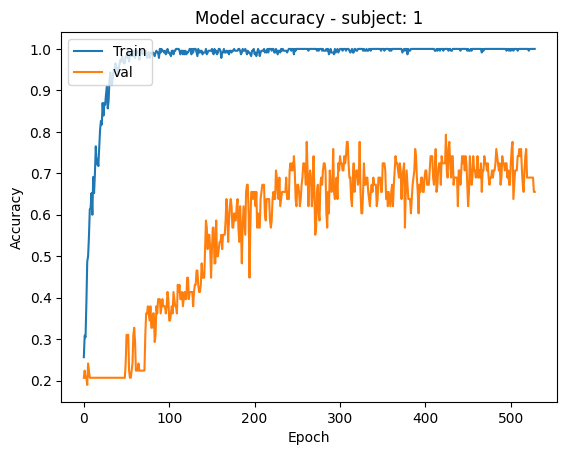

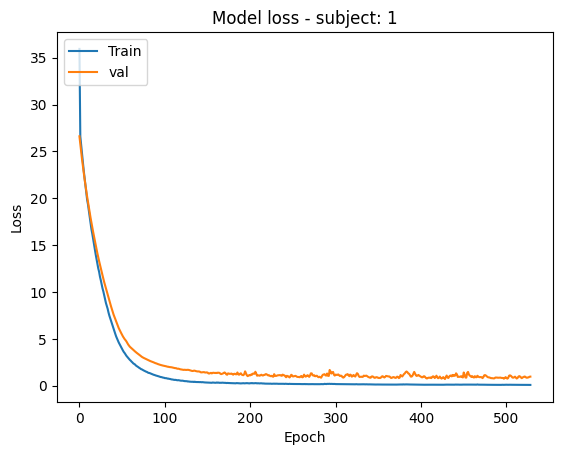


Training on subject  2


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 353: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 2   seed 1   time: 4.3 m   valid_acc: 0.6207   valid_loss: 1.109
Epoch 615: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 2   seed 2   time: 5.7 m   valid_acc: 0.7414   valid_loss: 0.815
Epoch 573: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 2   seed 3   time: 5.3 m   valid_acc: 0.7759   valid_loss: 0.729
Plot Learning Curves ....... 


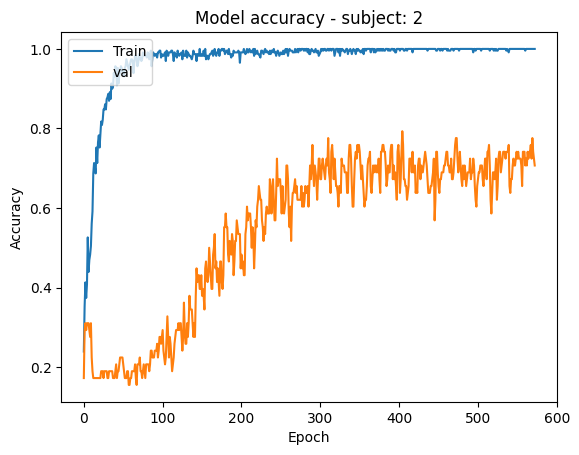

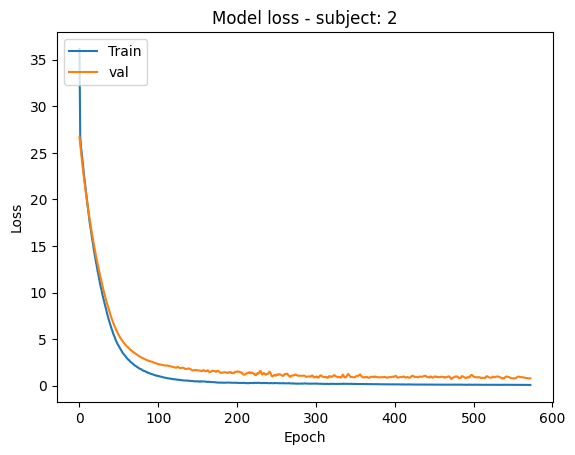


Training on subject  3


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 419: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 3   seed 1   time: 4.7 m   valid_acc: 0.8793   valid_loss: 0.516
Epoch 541: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 3   seed 2   time: 5.6 m   valid_acc: 0.9138   valid_loss: 0.304
Epoch 513: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 3   seed 3   time: 5.2 m   valid_acc: 0.9483   valid_loss: 0.285
Plot Learning Curves ....... 


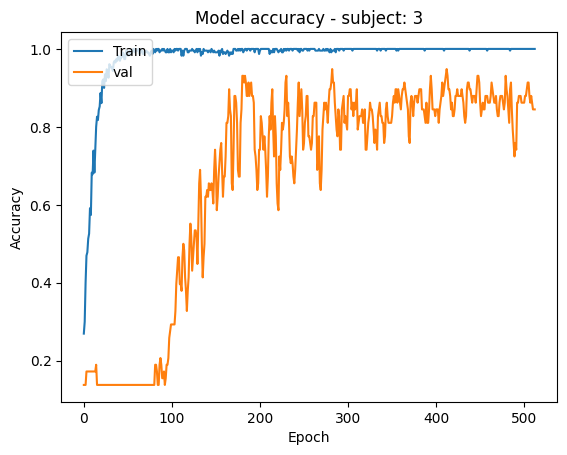

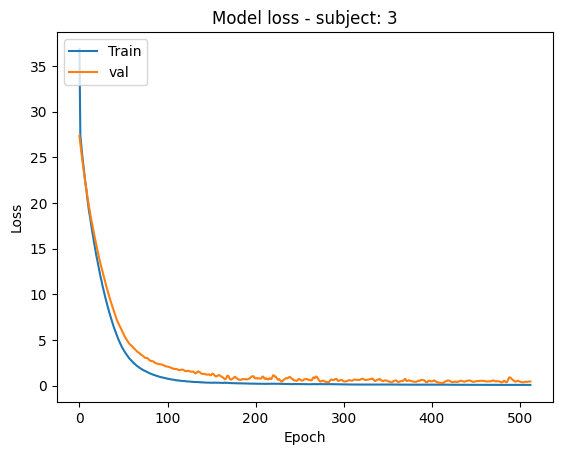


Training on subject  4


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 602: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 4   seed 1   time: 5.7 m   valid_acc: 0.8103   valid_loss: 0.644
Epoch 674: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 4   seed 2   time: 5.9 m   valid_acc: 0.8276   valid_loss: 0.638
Epoch 508: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 4   seed 3   time: 5.1 m   valid_acc: 0.8103   valid_loss: 0.684
Plot Learning Curves ....... 


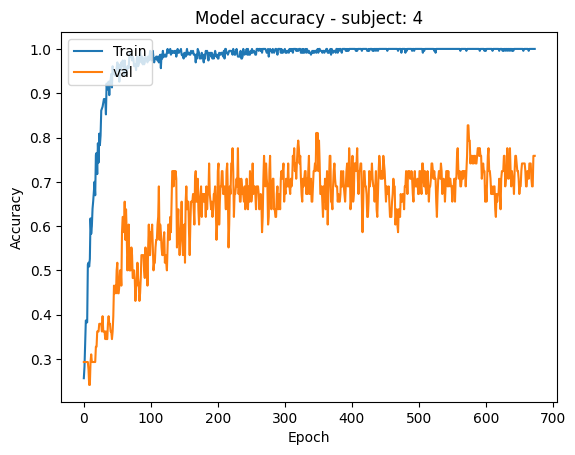

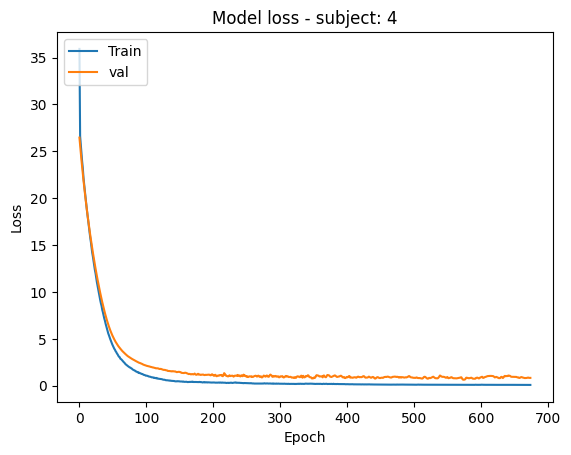


Training on subject  5


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 358: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 5   seed 1   time: 4.3 m   valid_acc: 0.8103   valid_loss: 0.629
Epoch 562: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 5   seed 2   time: 5.5 m   valid_acc: 0.7931   valid_loss: 0.598
Epoch 481: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
Subject: 5   seed 3   time: 5.1 m   valid_acc: 0.8621   valid_loss: 0.504
Plot Learning Curves ....... 


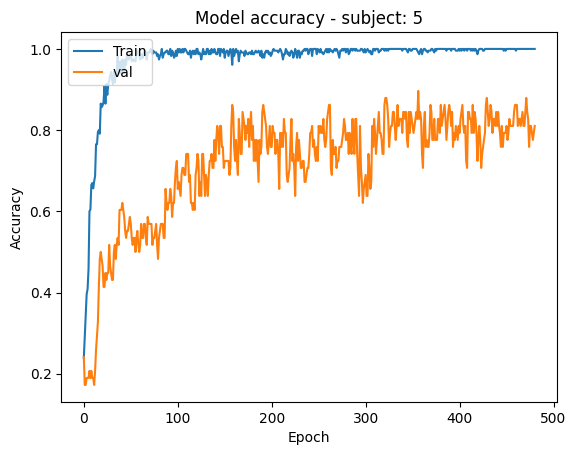

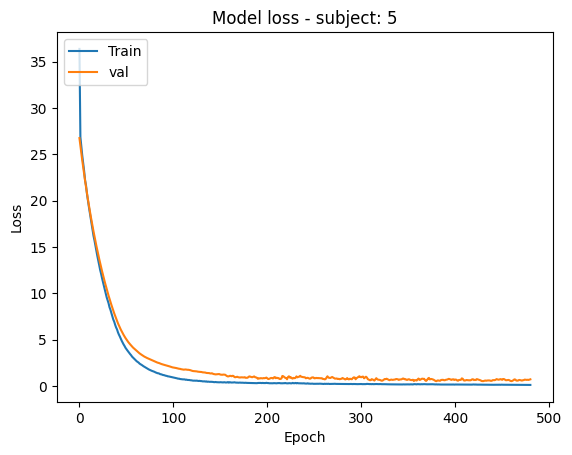


Training on subject  6


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 642: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 6   seed 1   time: 5.8 m   valid_acc: 0.7414   valid_loss: 0.782
Epoch 780: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Subject: 6   seed 2   time: 6.5 m   valid_acc: 0.6897   valid_loss: 0.661
Epoch 436: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 6   seed 3   time: 5.1 m   valid_acc: 0.7759   valid_loss: 0.739
Plot Learning Curves ....... 


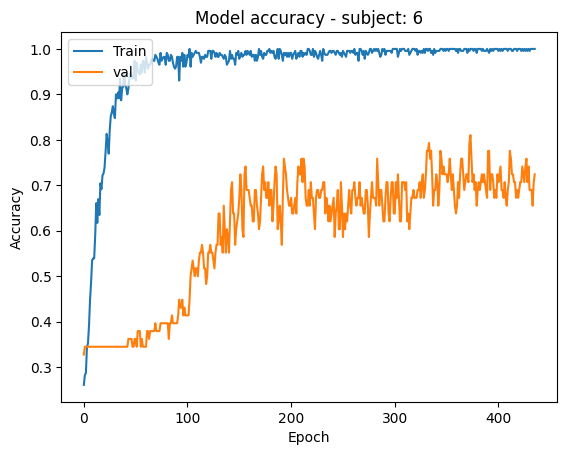

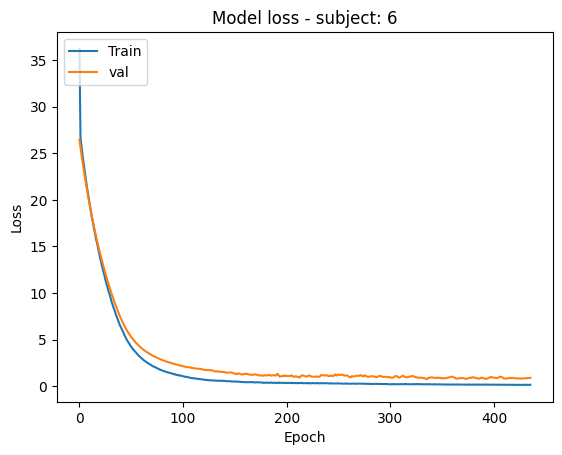


Training on subject  7


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 439: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 7   seed 1   time: 4.7 m   valid_acc: 0.9655   valid_loss: 0.228
Epoch 694: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 7   seed 2   time: 5.9 m   valid_acc: 0.8966   valid_loss: 0.424
Epoch 326: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Subject: 7   seed 3   time: 4.1 m   valid_acc: 0.7759   valid_loss: 0.760
Plot Learning Curves ....... 


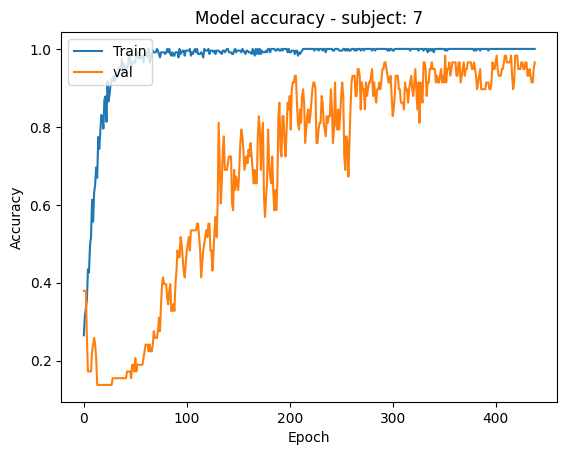

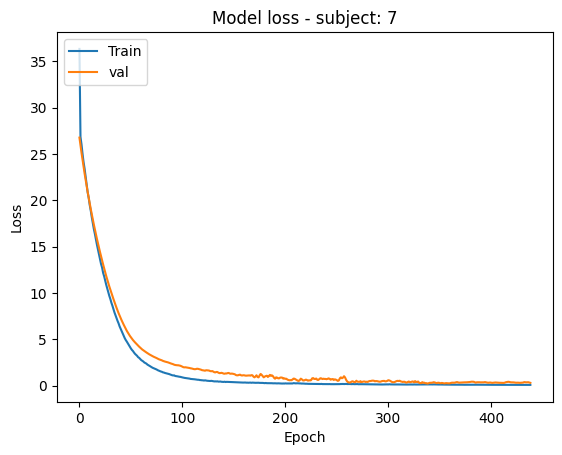


Training on subject  8


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 408: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step
Subject: 8   seed 1   time: 4.5 m   valid_acc: 0.8621   valid_loss: 0.541
Epoch 607: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 8   seed 2   time: 5.7 m   valid_acc: 0.8793   valid_loss: 0.389
Epoch 447: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 8   seed 3   time: 5.0 m   valid_acc: 0.8966   valid_loss: 0.431
Plot Learning Curves ....... 


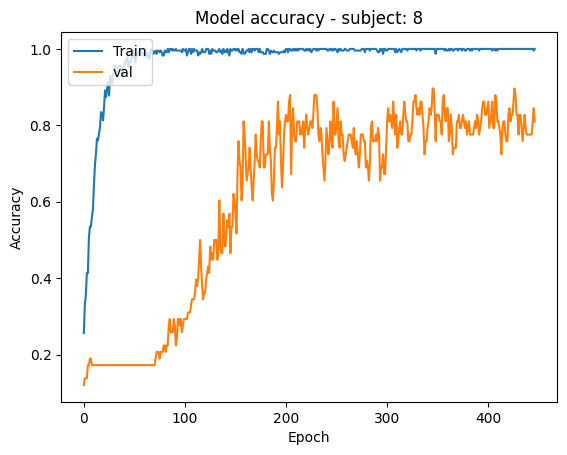

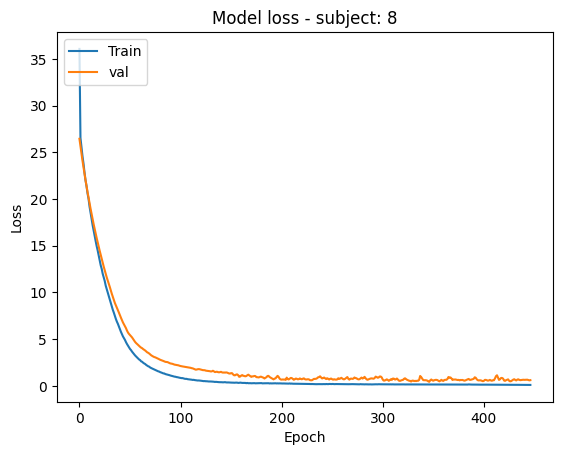


Training on subject  9


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
Epoch 729: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step
Subject: 9   seed 1   time: 6.5 m   valid_acc: 1.0000   valid_loss: 0.131
Epoch 755: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 9   seed 2   time: 6.5 m   valid_acc: 1.0000   valid_loss: 0.117
Epoch 817: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step
Subject: 9   seed 3   time: 6.9 m   valid_acc: 1.0000   valid_loss: 0.103
Plot Learning Curves ....... 


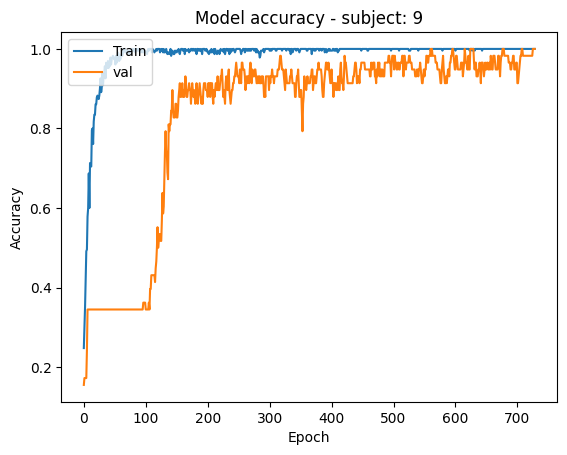

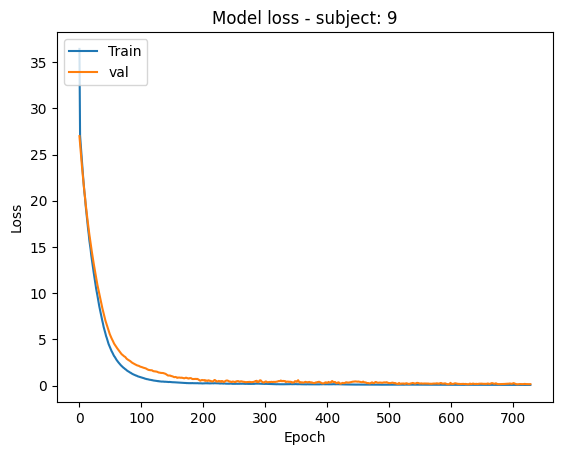


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  77.59   62.07   87.93   81.03   81.03   74.14   96.55   86.21   100.00     82.95   
Seed 2:  70.69   74.14   91.38   82.76   79.31   68.97   89.66   87.93   100.00     82.76   
Seed 3:  70.69   77.59   94.83   81.03   86.21   77.59   77.59   89.66   100.00     83.91   
---------------------------------
Average acc - all seeds: 83.21 %

Train Time  - all seeds: 143.6 min
---------------------------------

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

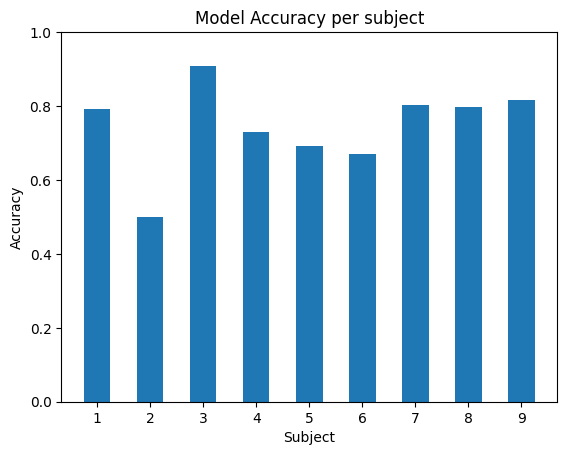

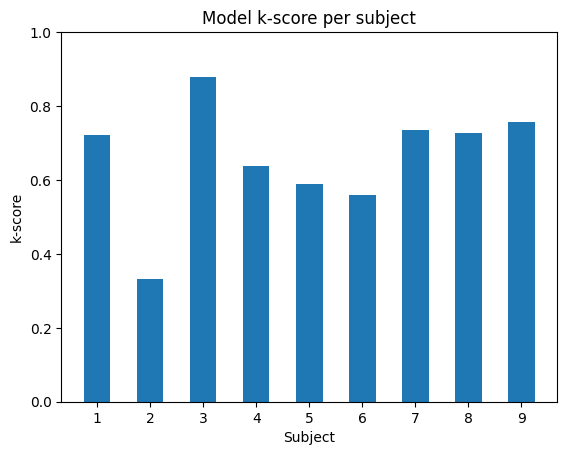

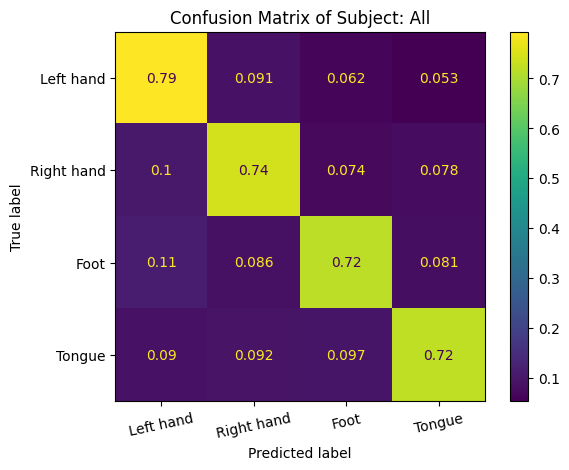

In [15]:
run("none")